In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [2]:
oil_prices = pd.read_csv('proj2_data/oil_prices_daily.csv')
iran_exp = pd.read_csv('proj2_data/iran_oil_exports.csv')
geopol_events = pd.read_csv('proj2_data/geopolitical_events.csv')
risk_indicators = pd.read_csv('proj2_data/risk_indicators.csv')
sanctions = pd.read_csv('proj2_data/sanctions_timeline.csv')
dati = pd.read_csv('proj2_data/petrolio_hor.csv')

In [31]:
dati

,date,brent_usd,wti_usd,dubai_usd,brent_wti_spread,brent_daily_return_pct,brent_30d_vol,hormuz_risk_premium_pct,is_geopolitical_event,opec_production_mbd,...,sanctions_has_event,sanctions_imposing_authority,sanctions_type,sanctions_category,sanctions_description,sanctions_gdp_impact_pct,sanctions_oil_sector_affected,sanctions_financial_sector_affected,sanctions_is_relief,sanctions_cumulative_pressure
0,1990-01-02,21.20,22.88,17.70,-1.68,NaN,NaN,3.00,0,NaN,...,0,NaN,NaN,NaN,NaN,0.0,0,0,0,0.00
1,1990-01-03,22.65,23.81,19.15,-1.16,6.8396,NaN,3.00,0,NaN,...,0,NaN,NaN,NaN,NaN,0.0,0,0,0,0.00
2,1990-01-04,22.50,23.41,19.00,-0.91,-0.6623,NaN,3.00,0,NaN,...,0,NaN,NaN,NaN,NaN,0.0,0,0,0,0.00
3,1990-01-05,23.13,23.07,19.63,0.06,2.8000,NaN,3.00,0,NaN,...,0,NaN,NaN,NaN,NaN,0.0,0,0,0,0.00
4,1990-01-08,21.38,21.64,17.88,-0.26,-7.5659,NaN,3.00,0,NaN,...,0,NaN,NaN,NaN,NaN,0.0,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9204,2026-04-20,103.40,91.06,102.66,12.34,4.8363,6.6773,7.38,1,19.86,...,0,NaN,NaN,NaN,NaN,0.0,0,0,0,1.59
9205,2026-04-21,98.48,92.13,97.74,6.35,-4.7582,6.6018,8.56,0,19.86,...,0,NaN,NaN,NaN,NaN,0.0,0,0,0,1.59
9206,2026-04-22,101.91,92.96,101.17,8.95,3.4829,6.6179,7.68,0,19.86,...,0,NaN,NaN,NaN,NaN,0.0,0,0,0,1.59
9207,2026-04-23,105.07,95.85,104.33,9.22,3.1008,6.5583,7.87,0,19.86,...,0,NaN,NaN,NaN,NaN,0.0,0,0,0,1.59


## **Analisi e creazione dei dati**

In [3]:

dati['geopol_event_type_filled'] = dati['geopol_event_type'].fillna('none')
dati['geopol_region_filled'] = dati['geopol_region'].fillna('none')
dati['geopol_shock_direction_filled'] = dati['geopol_shock_direction'].fillna('none')
dati['geopol_severity_filled'] = dati['geopol_severity'].fillna('none')
dati['sanctions_imposing_authority_filled'] = dati['sanctions_imposing_authority'].fillna('none')

event_type_map = {'none': 0, 'diplomatic': 1, 'terror': 2, 'political': 3, 'sanctions':4, 'market':5, 'economic':6, 'military': 7}
dati['event_type_encoded'] = dati['geopol_event_type_filled'].map(event_type_map)

region_map = {'none': 0, 'Middle East': 1, 'Global': 2}
dati['region_encoded'] = dati['geopol_region_filled'].map(region_map)

shock_dir_map = {'none': 0, 'up': 1, 'down': 2}
dati['shock_dir_encoded'] = dati['geopol_shock_direction_filled'].map(shock_dir_map)

severity_map = {'none': 0, 'low': 1, 'medium': 2, 'high': 3, 'extreme': 4}
dati['severity_encoded'] = dati['geopol_severity_filled'].map(severity_map)

imposing_authority_map = {'none': 0, 'US': 1, 'EU': 2, 'UN': 3, 'US/EU': 4, 'US/EU/UN': 5}
dati['imposing_authority_encoded'] = dati['sanctions_imposing_authority_filled'].map(imposing_authority_map)

#sanc_category_map = {'asset_freeze': 1, 'trade_ban': 2, 'secondary_sanctions': 3, 'nuclear_sanctions': 4, 'comprehensive': 5, 'financial': 6, 'oil_embargo': 7, 'oil_sanctions': 8, 'partial_relief': 9 }

features = ['opec_production_mbd', 'us_rig_count', 'geopolitical_risk_index', 'iran_specific_risk_bp', 'vix_index', 
            'usd_index_dxy', 'gold_usd_oz', 'opec_spare_capacity_mbd', 'brent_risk_premium_usd', 'energy_security_index',
            'geopol_has_event', 'event_type_encoded', 'region_encoded', 'geopol_iran_involved', 'geopol_price_shock_pct', 'shock_dir_encoded',
            'geopol_duration_days', 'severity_encoded', 'geopol_strait_of_hormuz_risk', 'geopol_sanctions_related', 'geopol_military_action',
            'sanctions_has_event', 'imposing_authority_encoded', 'sanctions_gdp_impact_pct', 'sanctions_oil_sector_affected',
            'sanctions_financial_sector_affected', 'sanctions_is_relief', 'sanctions_cumulative_pressure'  
            ]

dati[features] = dati[features].fillna(0)

X_full = np.transpose(np.vstack([dati[feat] for feat in features]))
X = X_full[365:, :]
X_2026 = X_full[:365, :]

threshold_brent = 100.0 #threshold on the price [usd]
labels_full = [int(dati['brent_usd'][i] >= threshold_brent) for i in range(len(dati['brent_usd']))]
labels = labels_full[365:]
labels_2026 = labels_full[:365]


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, labels, train_size=0.82, stratify=labels)

In [52]:
SC = StandardScaler()
scaled_X_train = SC.fit_transform(X_train)

## Principal component analysis

In [ ]:
pca = PCA(n_components=20)
reduced_X_train = pca.fit_transform(scaled_X_train)

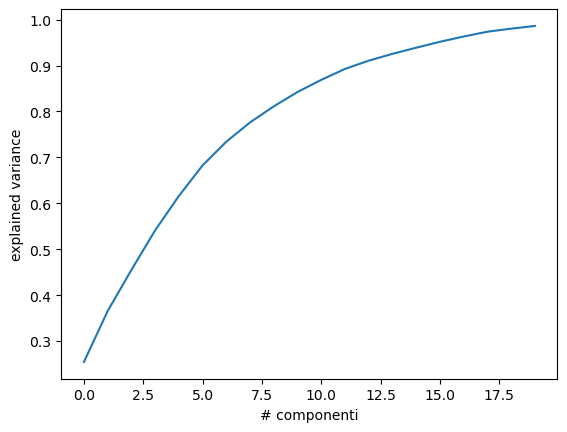

In [54]:
cum_sum_eig = np.cumsum(pca.explained_variance_ratio_)
plt.plot(np.arange(0, len(reduced_X_train[1])), cum_sum_eig)
plt.xlabel('# componenti')
plt.ylabel('explained variance')
plt.savefig('PCA.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
for i in range(len(pca.components_)): print ([i], pca.explained_variance_ratio_[i])

[0] 0.25459691460343437
[1] 0.11084902683663163
[2] 0.08947793340147472
[3] 0.08620321855656624
[4] 0.07485268226097855
[5] 0.06659153193575666
[6] 0.05163597220199289
[7] 0.0419477105405167
[8] 0.03499323783995989
[9] 0.031204525464053813
[10] 0.026451820118231287
[11] 0.023799648249723516
[12] 0.017993570436377844
[13] 0.014856484705540147
[14] 0.013314657364717642
[15] 0.01290446761753716
[16] 0.011478134230925741
[17] 0.010474760149352533
[18] 0.0065851850554870545
[19] 0.006003334901545738


## Training

In [63]:
accuracy_CV = []
accuracy_int = []
accuracy_2026 = []

for run in range(10):

    X_train, X_test, y_train, y_test = train_test_split(X, labels, train_size=0.82, stratify=labels)
    SC = StandardScaler()
    scaled_X_train = SC.fit_transform(X_train)

    k = [2, 4, 8, 16] #number of folds
    k_accuracy = []
    param_grid = {'C': [0.001, 0.01, 0.1, 1, 10], 'kernel': ('linear', 'poly')} # hyperparameters to check
    best_CV_model = GridSearchCV(SVC(), param_grid=param_grid)

    for splits in k:
        skf = StratifiedKFold(n_splits=splits, shuffle=True) #manually creates partitions
        CV_model = GridSearchCV(SVC(), param_grid=param_grid, cv=skf) #search over hyperparameters using CV
        CV_model.fit(scaled_X_train, y_train) #finds best hyperparameter on Training patterns
        k_accuracy.append(CV_model.best_score_)
        if CV_model.best_score_ == np.max(np.array(k_accuracy)):
            best_CV_model = CV_model

    accuracy_CV.append(best_CV_model.best_score_)

    if (run == 5):
        print(f"best C: {CV_model.best_params_['C']}") #best hyperparameter found
        print(f"best kernel: {CV_model.best_params_['kernel']}")
        best_CV_model.best_score_ #accuracy obtained with best hyperparameter
        print(k_accuracy)
    
    SVM = SVC(kernel = best_CV_model.best_params_['kernel'], C = best_CV_model.best_params_['C']) #configures SVM with best iperparameter found
    SVM.fit(scaled_X_train, y_train) #training to find the best linear hyperplane
    scaled_X_test = SC.transform(X_test)
    #reduced_X_test = pca.transform(scaled_X_test)
    y_predict = SVM.predict(scaled_X_test)
    print(accuracy_score(y_test, y_predict))
    accuracy_int.append(accuracy_score(y_test, y_predict))

    scaled_X_2026 = SC.transform(X_2026)
    #reduced_X_test = pca.transform(scaled_X_test)
    SVM.predict(scaled_X_2026)
    y_predict_2026 = SVM.predict(scaled_X_2026)
    print(accuracy_score(labels_2026, y_predict_2026))
    accuracy_2026.append(accuracy_score(labels_2026, y_predict_2026))

print('------------------------------------------------------------------')
print('Accuracy in CV: '+str(np.mean(accuracy_CV))+' +- '+str(np.std(accuracy_CV)))
print('Accuracy on internal testing: '+str(np.mean(accuracy_int))+' +- '+str(np.std(accuracy_int)))
print('Accuracy on 2026 data: '+str(np.mean(accuracy_2026))+' +- '+str(np.std(accuracy_2026)))

0.9836683417085427
0.9945205479452055
0.9836683417085427
0.9917808219178083
0.9792713567839196
0.9917808219178083
0.9786432160804021
0.9972602739726028
0.9905778894472361
0.9945205479452055
best C: 10
best kernel: poly
[np.float64(0.9790402647545504), np.float64(0.9813844456701599), np.float64(0.9833142580031202), np.float64(0.9833148564148944)]
0.9817839195979899
0.9945205479452055
0.9805276381909548
0.9972602739726028
0.9817839195979899
0.9945205479452055
0.9748743718592965
0.9945205479452055
0.9824120603015075
0.9945205479452055
------------------------------------------------------------------
Accuracy in CV: 0.9826671951172022 +- 0.0008853566714537144
Accuracy on internal testing: 0.9817211055276382 +- 0.0038767020412586372
Accuracy on 2026 data: 0.9945205479452055 +- 0.0017327548822840364


In [4]:
accuracy_CV = []
accuracy_int = []
accuracy_2026 = []

for run in range(10):

    X_train, X_test, y_train, y_test = train_test_split(X, labels, train_size=0.82, stratify=labels)
    SC = StandardScaler()
    scaled_X_train = SC.fit_transform(X_train)
    pca = PCA(n_components=10)
    reduced_X_train = pca.fit_transform(scaled_X_train)
    print('pca applied!')
    

    k = [2, 4, 8, 16] #number of folds
    k_accuracy = []
    param_grid = {'C': [0.001, 0.01, 0.1, 1, 10], 'kernel': ('linear', 'poly')} # hyperparameters to check
    best_CV_model = GridSearchCV(SVC(), param_grid=param_grid)

    for splits in k:
        skf = StratifiedKFold(n_splits=splits, shuffle=True) #manually creates partitions
        CV_model = GridSearchCV(SVC(), param_grid=param_grid, cv=skf) #search over hyperparameters using CV
        CV_model.fit(reduced_X_train, y_train) #finds best hyperparameter on Training patterns
        k_accuracy.append(CV_model.best_score_)
        if CV_model.best_score_ == np.max(np.array(k_accuracy)):
            best_CV_model = CV_model

    accuracy_CV.append(best_CV_model.best_score_)

    if (run == 5):
        print(f"best C: {CV_model.best_params_['C']}") #best hyperparameter found
        print(f"best kernel: {CV_model.best_params_['kernel']}")
        best_CV_model.best_score_ #accuracy obtained with best hyperparameter
        print(k_accuracy)
    
    SVM = SVC(kernel = best_CV_model.best_params_['kernel'], C = best_CV_model.best_params_['C']) #configures SVM with best iperparameter found
    SVM.fit(reduced_X_train, y_train) #training to find the best linear hyperplane
    scaled_X_test = SC.transform(X_test)
    reduced_X_test = pca.transform(scaled_X_test)
    y_predict = SVM.predict(reduced_X_test)
    print(accuracy_score(y_test, y_predict))
    accuracy_int.append(accuracy_score(y_test, y_predict))

    scaled_X_2026 = SC.transform(X_2026)
    reduced_X_2026 = pca.transform(scaled_X_2026)
    #reduced_X_test = pca.transform(scaled_X_test)
    y_predict_2026 = SVM.predict(reduced_X_2026)
    print(accuracy_score(labels_2026, y_predict_2026))
    accuracy_2026.append(accuracy_score(labels_2026, y_predict_2026))

print('------------------------------------------------------------------')
print('Accuracy in CV: '+str(np.mean(accuracy_CV))+' +- '+str(np.std(accuracy_CV)))
print('Accuracy on internal testing: '+str(np.mean(accuracy_int))+' +- '+str(np.std(accuracy_int)))
print('Accuracy on 2026 data: '+str(np.mean(accuracy_2026))+' +- '+str(np.std(accuracy_2026)))

pca applied!
0.9748743718592965
0.9917808219178083
pca applied!
0.9780150753768844
0.9945205479452055
pca applied!
0.9673366834170855
0.9095890410958904
pca applied!
0.9786432160804021
0.9972602739726028
pca applied!
0.9792713567839196
0.989041095890411
pca applied!
best C: 10
best kernel: poly
[np.float64(0.971180364037507), np.float64(0.9735245449531162), np.float64(0.9733870241511327), np.float64(0.9744887849967422)]
0.9811557788944724
0.9945205479452055
pca applied!
0.9748743718592965
1.0
pca applied!
0.9786432160804021
0.7561643835616438
pca applied!
0.9729899497487438
0.9945205479452055
pca applied!
0.9786432160804021
0.9972602739726028
------------------------------------------------------------------
Accuracy in CV: 0.9739793373520657 +- 0.001390739107263212
Accuracy on internal testing: 0.9764447236180904 +- 0.003833717215996765
Accuracy on 2026 data: 0.9624657534246577 +- 0.07337199092538678
